In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression, make_classification
import matplotlib.pyplot as plt

In [ ]:
X, y = make_regression(n_samples=1000, n_features=2, noise=20)

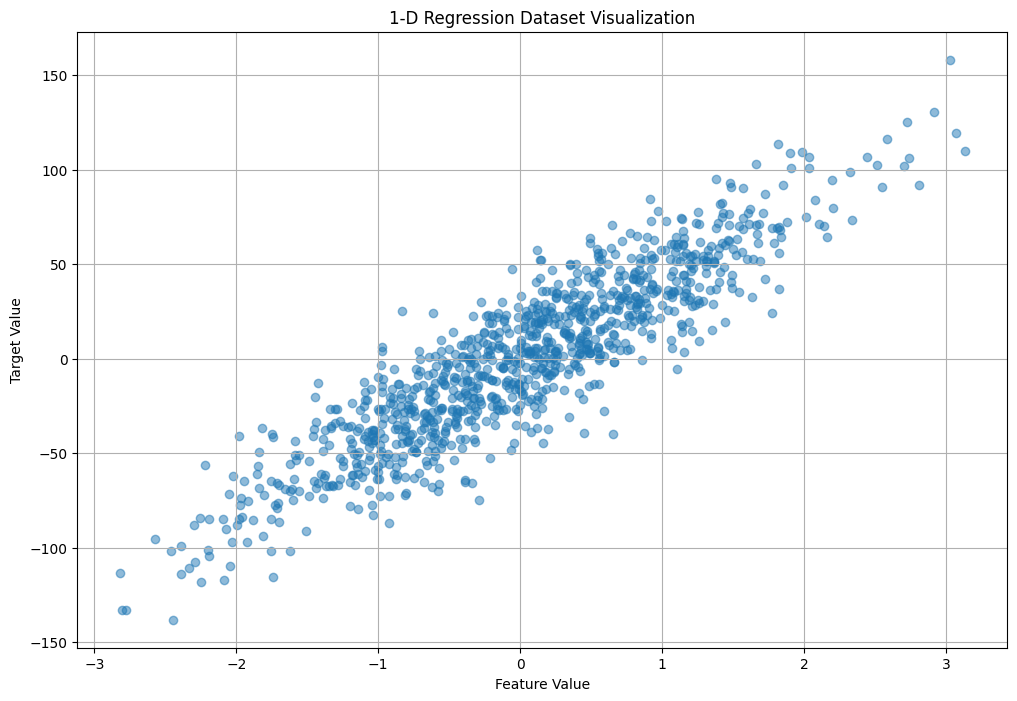

In [ ]:
plt.figure(figsize=(12, 8))  # Set the figure size for better readability
plt.scatter(X, y, alpha=0.5)  # Plot the points with some transparency to see density
plt.title("1-D Regression Dataset Visualization")
plt.xlabel("Feature Value")
plt.ylabel("Target Value")
plt.grid(True)  # Add a grid for easier visualization
plt.show()

In [ ]:
def distance(point1, point2):

  '''
  function for cmputing an auclidian distance
  point1 = [x1,x2,......xn]
  point2 = [x1,x2,.....xn]

  n - dimentionality
  '''
  n = len(point1)
  dist = 0

  for i in range(n):
    dist += (point1[i] - point2[i])**2

  dist = dist**0.5


  return dist

In [ ]:
distance([0,0],[1,1])

1.4142135623730951

In [ ]:
def dist_array(point, X, y):
  arr = []

  for i, p in enumerate(X):
    arr.append(distance(point, p))

  df_temp = pd.DataFrame(X)
  df_temp['y'] = y
  df_temp['dist'] = arr

  return df_temp.sort_values('dist')

In [ ]:
def w_dist_array(point, X, y, pow):

  w = []
  arr = []
  for i ,p in enumerate(X):
    if distance(point, p) == 'error':
      return 'error'
    else:
      arr.append(distance(point,p))
      w.append(1/(distance(point,p)**pow))

  df_temp = pd.DataFrame(X)
  df_temp['y'] = y
  df_temp['dist'] = arr
  df_temp['w'] = w
  return df_temp.sort_values('dist')

In [ ]:
w_dist_array([1,0], X, y, 1)

,0,1,y,dist,w
822,1.071346,-0.043193,34.538565,0.083402,11.990116
966,0.985803,0.104393,69.279611,0.105354,9.491846
260,0.977878,-0.122212,52.170484,0.124198,8.051656
155,1.055718,-0.119560,27.125144,0.131906,7.581161
454,0.897441,-0.084071,24.335099,0.132613,7.540737
...,...,...,...,...,...
255,-2.563547,-0.993612,-214.462219,3.699477,0.270308
150,-2.685848,-0.480894,-156.790930,3.717087,0.269028
133,-2.711531,0.266877,-89.041041,3.721113,0.268737
569,-2.187649,2.282580,93.184131,3.920622,0.255062


In [ ]:
# y

In [ ]:
def w_prediction(df_temp, k):

  df_top_k = df.temp.head(k)
  w = df_top_k['w']
  y = df_top_k['y']
  w_pred = 0

  for i in range(k):
    w_pred += w[i]*y[i]

  return w_pred/sum(w)

In [ ]:
dist_array([1],X,y)

,0,1,y,dist
677,1.003204,-1.229433,-0.461627,0.003204
511,1.010093,0.643847,91.352061,0.010093
224,1.010600,-1.235221,-20.428574,0.010600
298,1.011675,1.003840,58.740191,0.011675
195,1.013599,-0.644261,27.169061,0.013599
...,...,...,...,...
967,-2.843349,-1.524942,-75.984627,3.843349
997,-2.892466,-2.639372,-173.550006,3.892466
82,-2.908349,-0.647507,-82.145245,3.908349
736,-2.956602,-0.292554,-67.316149,3.956602


In [ ]:
def prediction(df_temp, k):
  '''
  df_temp - a dataframe with calculated distance in column 'dist' and y_true values in 'y' column k - number of closest elements \

    return y_predicted
  '''
  df_top_k = df_temp.head(k)
  y_predicted = df_top_k['y'].mean()

  return y_predicted

In [ ]:
def Knn_reg(X, y, k, point):
  '''
  simple kNN regression
  X, y - dataset
  point - the point to make prediction for k-number of closest elements
  '''
  # df_temp = dist_array(point, X, y)

  # y_predicted = prediction(df_temp, k)


  dist_arr = dist_array(point, X ,y)
  pred = prediction(dist_arr, k)

  return pred

In [ ]:
Knn_reg(X,y, 10, [2])

70.21824182405497